# Predict population density

In this notebook we will aim to predict the population density in the London MSOA (Middle layer Super Output Area) regions.

We will use open data form the London datastore and try to predict the population using features from the Overture Maps dataset.

<a target="_blank" href="https://colab.research.google.com/github/kraina-ai/srai-tutorial/blob/geopython2025/03_london_population_density_prediction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
## Uncomment the line below when running on Google Colab
# %pip install srai[overturemaps] openpyxl contextily seaborn

## Prepare London population dataset

We will download geometries for the MSOA (Middle layer Super Output Area) regions for London from 2021 and combine it with population estimates for 2022.

Based on that we will calculate population density and try to predict it.

In [17]:
import zipfile
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from pooch import retrieve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from srai.embedders import CountEmbedder
from srai.loaders import OvertureMapsLoader
from srai.regionalizers import convert_to_regions_gdf

### Download geometries for the MSOA regions

In [3]:
msoa_url = "https://data.london.gov.uk/download/statistical-gis-boundary-files-london/f6d9340a-2ccb-46ad-846b-c9122b4b5d1f/LB_MSOA2021_shp.zip"
destination_file = retrieve(
    url=msoa_url,
    fname=Path(msoa_url).name,
    path=".",
    known_hash=None,
)

SHA256 hash of downloaded file: 8bbc983630d0906fbe2eb782d11646dc24278016b59e23966d22febaae574ded
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [4]:
zip_path = destination_file
zip_paths = []

with zipfile.ZipFile(zip_path, mode="r") as archive:
    zip_paths = [
        f"zip:{zip_path}!{p}" for p in archive.namelist() if p.endswith(".shp")
    ]

zip_paths

['zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Barking and Dagenham.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Barnet.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Bexley.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Brent.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Bromley.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Camden.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/City of London.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Croydon.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Ealing.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Enfield.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Greenwich.shp',
 'zip:/Users/raczeq/dev/srai-tutorial/LB_MSOA2021_shp.zip!msoa2021/Hackney.shp',
 'zip:/Users

### Load MSOA boundaries

We will load each SHP from inside the zip file and concatenate the results.

In [5]:
msoa_gdf = gpd.pd.concat(
    [gpd.read_file(p, columns=["msoa21cd", "msoa21nm", "geometry"]) for p in zip_paths]
)
msoa_gdf

,msoa21cd,msoa21nm,geometry
0,E02000009,Barking and Dagenham 008,"POLYGON ((546799.421 186249.956, 546805.432 18..."
1,E02000012,Barking and Dagenham 011,"POLYGON ((546238.761 185409.344, 546238.943 18..."
2,E02000015,Barking and Dagenham 014,"POLYGON ((549964.554 184818.777, 549966.393 18..."
3,E02000016,Barking and Dagenham 015,"POLYGON ((544113.724 184901.614, 544129.714 18..."
4,E02000017,Barking and Dagenham 016,"POLYGON ((544701.411 185122.589, 544760.577 18..."
...,...,...,...
19,E02000982,Westminster 023,"POLYGON ((529117.206 178950.444, 529123.997 17..."
20,E02000983,Westminster 024,"MULTIPOLYGON (((528603.045 177937.412, 528597...."
21,E02000960,Westminster 001,"POLYGON ((526726.313 183732.5, 526726.98 18372..."
22,E02000972,Westminster 013,"POLYGON ((528891.318 182198.838, 528891.032 18..."


Notice the coordinates in the geometries aren't in the WGS84 CRS.

They are saved in the projected CRS EPSG:27700, which is the British National Grid, with units in meters.

In [6]:
msoa_gdf.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

### Download and load MSOA statistics

We will load the statistics for the year of 2021.

In [7]:
stats = "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/middlesuperoutputareamidyearpopulationestimatesnationalstatistics/mid2021andmid2022/sapemsoaquinaryagetablefinal.xlsx"
destination_file = retrieve(
    url=stats,
    fname="msoa_density.xlsx",
    path=".",
    known_hash=None,
)

x = pd.read_excel(
    destination_file,
    sheet_name="Mid-2022 MSOA 2021",
    skiprows=3,
)[["MSOA 2021 Code", "Total"]]
x

SHA256 hash of downloaded file: f0b1bb586f55a06084d4aa20889e35a7d35e3d4dc682b6396b7ec69b92089320
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


,MSOA 2021 Code,Total
0,E02002483,10323
1,E02002484,10460
2,E02002485,8040
3,E02002489,7312
4,E02002490,5824
...,...,...
7259,W02000286,6795
7260,W02000287,8299
7261,W02000288,8041
7262,W02000289,8688


### Combine geometries with statistics

Here we will combine geometries GeoDataFrame with population per region.

Then we will calculate the area (since the geometries are in the projected CRS, it will calculate are properly in meters squared).

After calculating the area we can change the CRS to WGS84 (or EPSG:4326).

In [18]:
msoa_stats_gdf = msoa_gdf.merge(x, left_on="msoa21cd", right_on="MSOA 2021 Code")
msoa_stats_gdf["area"] = msoa_stats_gdf.area
msoa_stats_gdf["population_density"] = msoa_stats_gdf["Total"] / msoa_stats_gdf["area"]
msoa_stats_gdf = convert_to_regions_gdf(msoa_stats_gdf.to_crs(epsg=4326).set_index("msoa21cd"))
msoa_stats_gdf

,msoa21nm,geometry,MSOA 2021 Code,Total,area,population_density
region_id,,,,,,
E02000009,Barking and Dagenham 008,"POLYGON ((0.11613 51.55604, 0.11621 51.55589, ...",E02000009,12850,9.615213e+05,0.013364
E02000012,Barking and Dagenham 011,"POLYGON ((0.1077 51.54863, 0.1077 51.54863, 0....",E02000012,11660,1.300308e+06,0.008967
E02000015,Barking and Dagenham 014,"POLYGON ((0.16114 51.54235, 0.16116 51.54226, ...",E02000015,8189,1.361638e+06,0.006014
E02000016,Barking and Dagenham 015,"POLYGON ((0.07686 51.54462, 0.07709 51.54444, ...",E02000016,10657,9.128385e+05,0.011675
E02000017,Barking and Dagenham 016,"POLYGON ((0.08542 51.54645, 0.08624 51.54559, ...",E02000017,9133,8.765691e+05,0.010419
...,...,...,...,...,...,...
E02000982,Westminster 023,"POLYGON ((-0.14145 51.49476, -0.14136 51.49466...",E02000982,7569,6.535906e+05,0.011581
E02000983,Westminster 024,"MULTIPOLYGON (((-0.14922 51.48577, -0.1493 51....",E02000983,7864,5.579600e+05,0.014094
E02000960,Westminster 001,"POLYGON ((-0.17415 51.53828, -0.17415 51.53823...",E02000960,6409,9.223202e+05,0.006949


### Plot the density

Let's see how the density is distributed across the city.

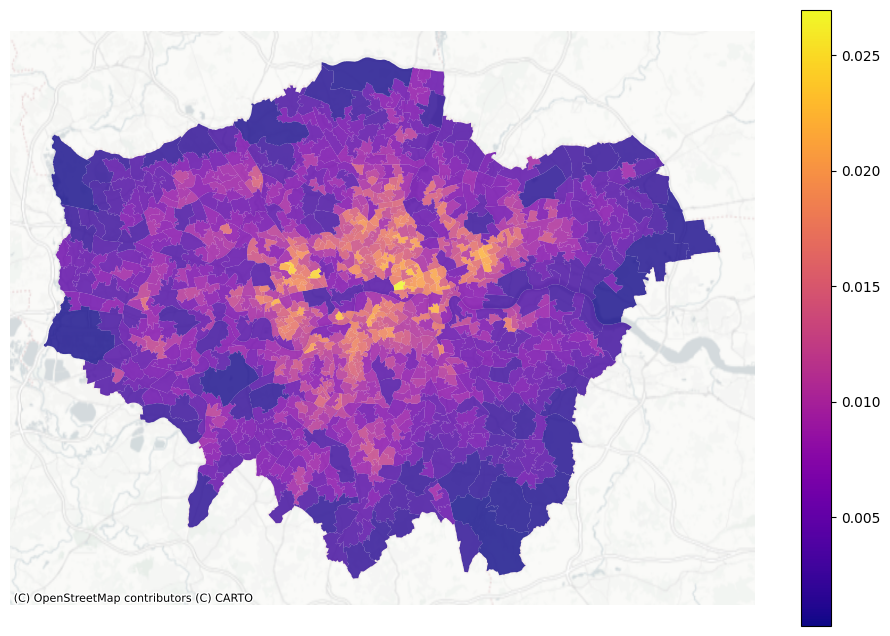

In [19]:
f, ax = plt.subplots(figsize=(12, 8))
msoa_stats_gdf.plot("population_density", ax=ax, legend=True, alpha=0.8, cmap="plasma")
cx.add_basemap(ax, crs=msoa_stats_gdf.crs, source=cx.providers.CartoDB.PositronNoLabels)
ax.set_axis_off()

plt.show()

## Generate embeddings

Let's now download the Overture Maps data and prepare some features for each region.

### Download the data using OvertureMapsLoader

In [20]:
london_features = OvertureMapsLoader(hierarchy_depth=1).load(msoa_stats_gdf)
london_features

Finished operation in 0:00:05

,geometry,base|infrastructure|aerialway,base|infrastructure|airport,base|infrastructure|barrier,base|infrastructure|bridge,base|infrastructure|communication,base|infrastructure|emergency,base|infrastructure|manhole,base|infrastructure|pedestrian,base|infrastructure|pier,...,places|place|professional_services,places|place|public_service_and_government,places|place|real_estate,places|place|religious_organization,places|place|retail,places|place|structure_and_geography,places|place|travel,transportation|segment|rail,transportation|segment|road,transportation|segment|water
feature_id,,,,,,,,,,,,,,,,,,,,,
121bd0fd-3f2e-4b39-8ae5-83b172bd1943,"LINESTRING (-0.49055 51.47211, -0.49209 51.472...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
f5b77fde-3b49-5a7c-9238-7c1d6eb60403,"POLYGON ((-0.5102 51.43729, -0.50997 51.43706,...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3d2b0aa1-f237-35df-bafe-8c2cea7ff2c9,"POLYGON ((-0.49344 51.46309, -0.4935 51.46309,...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
a23931d3-5aca-31b8-aae6-cf9b31ada54d,"POLYGON ((-0.49407 51.46378, -0.49418 51.4638,...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
68d2aa51-21c0-332e-88e8-cadbdb704872,POINT (-0.49406 51.46384),False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
da79abc0-fe90-4099-bdf2-29f48ac36db4,"LINESTRING (0.0905 51.37139, 0.09096 51.37078,...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
139e7828-f81b-4408-a265-ce7778bb9d04,"LINESTRING (0.26111 51.19462, 0.26108 51.19471...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5047c3cb-4627-3c98-b89c-029f59dc2944,"MULTIPOLYGON (((1.38426 51.14823, 1.38441 51.1...",False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Calculate intersections

To properly calculate which type of feature is in region, we need to know which geometries intersect between two datasets.

Here we will manually create and query spatial the STRTree index. In other examples we will use `IntersectionJoiner` from the srai library.

Because `CountEmbedder` expects dataframe as input, we will create an empty DataFrame with just an index.

In [21]:
region_idx, features_idx = london_features.sindex.query(
    msoa_stats_gdf.geometry, predicate="intersects"
)
features_per_msoa = pd.DataFrame(
    index=pd.MultiIndex.from_arrays(
        (msoa_stats_gdf.index[region_idx], london_features.index[features_idx]),
        names=(msoa_stats_gdf.index.name, london_features.index.name),
    )
)
features_per_msoa

Empty DataFrame
Columns: []
Index: [(E02000009, 17acf1eb-1fc3-3800-90c8-4bc6c5201848), (E02000009, 26824301-da5b-50a5-bf62-ecde6badb9dd), (E02000009, 5aaa9ade-179c-3943-b461-60477cc49fd1), (E02000009, cf836469-4f9b-5da1-925e-b73fdc11d593), (E02000009, c0e2c908-4895-323d-afce-003877cfc355), (E02000009, a18a8d07-ace2-33b1-b3e8-7493e40b7cd9), (E02000009, 4dd89cd4-c5c9-4d9a-87dd-43a2c91b7815), (E02000009, aeaf1dbb-26ae-4544-ad3c-c12a50c96569), (E02000009, c1597a40-08a0-4b3f-8bb4-05d57d4659a1), (E02000009, ec2c7183-7367-4761-83f2-1a5f3f3cc4c6), (E02000009, a52eb495-2748-457a-9292-6818eedb9bb6), (E02000009, 11514aae-29be-43f3-8c87-7a37a31fbfae), (E02000009, 7a28ad5a-4e3c-4592-b671-05c5474beebc), (E02000009, 9ac747d7-5932-3883-ab22-baa34bb65e02), (E02000009, 44f5e9a8-1018-41a6-9598-93a9be82ca35), (E02000009, 8a4cbbee-0723-3d22-97ae-81eb621b9eea), (E02000009, 7c96f46e-b956-4287-af05-bf1388aa4c1b), (E02000009, 2a325e88-dfab-3fbd-860f-38a45be25879), (E02000009, 2222a192-fa89-468e-bff3-5078350b1393), (E02000009, 37850b80-b5a4-4287-b119-5d0911cb703a), (E02000009, fac96800-f875-4476-96c0-aff630865210), (E02000009, 4e0005bf-3c5a-4616-8f9e-b86fd259c78f), (E02000009, 69446947-3c42-4ba6-b395-378a70a04864), (E02000009, 80653913-10b8-40aa-a966-e4aa48128a88), (E02000009, a424bd9c-d15c-4e6d-9722-472133a69e19), (E02000009, 6057b556-e9d1-4e3a-89fd-7af8b76282d8), (E02000009, 86aeddb3-96bb-3879-8962-0fb96bf3ecd1), (E02000009, 6ff28289-1b48-41f4-bd5e-3e0563a769df), (E02000009, 48d30a97-5120-4b87-a3d3-49f681c21ca8), (E02000009, 1edc36b3-3c61-4c84-86c9-502c59afe3ac), (E02000009, fe362367-8b66-4062-963f-479514cdb6ac), (E02000009, 8aaf6ae0-9c38-4abd-9656-2e7f9471b698), (E02000009, 514de8e7-d574-47c1-8dda-1527cb00b508), (E02000009, 9f53e6f1-88e0-4c11-9ad5-180a76597f34), (E02000009, a1762a20-e5d9-46f3-9624-0acbead4e7fa), (E02000009, c95fa2d7-2c43-49ba-907e-994120956362), (E02000009, 91855c5e-95e1-4d72-b8f6-c220291d7e4e), (E02000009, 40aa2305-c46b-473f-9c2a-c9d74af23a6a), (E02000009, 67b1d8d1-073b-4548-9cc0-a022792a9b71), (E02000009, 8950f0fb-42e2-418f-bde0-4402971f1a6d), (E02000009, d607f378-aa90-4989-85ca-e1c42ff10d91), (E02000009, d46da59c-ef4d-40f2-b2db-df60527d315b), (E02000009, f285ff6b-b6c5-41a0-b6c7-2133f5e7bb1b), (E02000009, b1e2ef1b-bc55-4a35-89c7-36eb53a50a40), (E02000009, fa1763e6-fd4b-425a-bd97-2c59ae3a7603), (E02000009, f51c0bbe-8e7e-4e10-a629-0f1dc5eeb586), (E02000009, 82038846-2b7f-4499-9a09-aeb62a05aefc), (E02000009, 4e111175-3890-4575-af05-c1adedcbad8a), (E02000009, c930bd48-537d-426d-b5c7-2d371318a723), (E02000009, a8c62825-3803-4f4b-afaf-69482bd68e35), (E02000009, 2ab16855-98e5-3230-8b83-fcca7b67a4a3), (E02000009, 2b19b16a-61a5-462d-ad5f-b22dde52d3a3), (E02000009, 80003094-c4ec-472b-ac25-0088c0647dd7), (E02000009, c1751ba3-2cad-40b9-aec2-24e16523d517), (E02000009, 90c801a3-5569-4d89-ba9e-5ca827158150), (E02000009, 72908bce-afa5-414f-8b02-c6043e56deaf), (E02000009, ba3ff29b-45db-4504-abb8-d72ebe026958), (E02000009, 752a84e4-acf0-43fe-bc36-fa63a0ef1dc9), (E02000009, d22f42ac-75cc-48e3-9520-853e7a3c6a0e), (E02000009, 2fe942af-188b-45f3-b1c9-470428732f10), (E02000009, cb23f30c-cfeb-4388-9ee6-4d502fcb3a39), (E02000009, 4dc31c4b-5fb3-4851-a2dc-ab4b485acdb8), (E02000009, aec3fe0b-80a9-41ee-9263-1c51fc9ed8c4), (E02000009, f326bbce-1111-4a42-ada1-1c4399244017), (E02000009, 1db9465f-4acb-4f52-94fc-1a4e84473c1c), (E02000009, 7b41c742-406c-4f71-9f20-75acc15d76c0), (E02000009, e00169e4-c0d6-402a-9ebb-cc4646915253), (E02000009, 1acfea97-e6a6-4958-8948-95cad0936709), (E02000009, b5ba32f0-0232-4a16-b264-25f36ff10aea), (E02000009, acf24f59-41b6-4ff6-929b-042d6e55e6a4), (E02000009, 8f2bb57b-80f2-43bc-b4fd-2ca4a968f47f), (E02000009, 62fb3c7e-11cb-4037-abf9-bbd0be44a1ec), (E02000009, 65c574f4-2986-474c-97ef-68e49bb68035), (E02000009, c30c1099-0673-411a-9d35-a67730dffdb9), (E02000009, 10f64713-e5c4-4d13-9373-92a07db0d6b5), (E02000009, 071928b2-ddd3-48a9-b792-43c50b429fcc), (E02000009, 61ed874e-f2b1-30ea-af18-3ac57c581ee7), (E02000009, 888ad17d-00b2-5bb5-bd6d-1

### Explore the input data

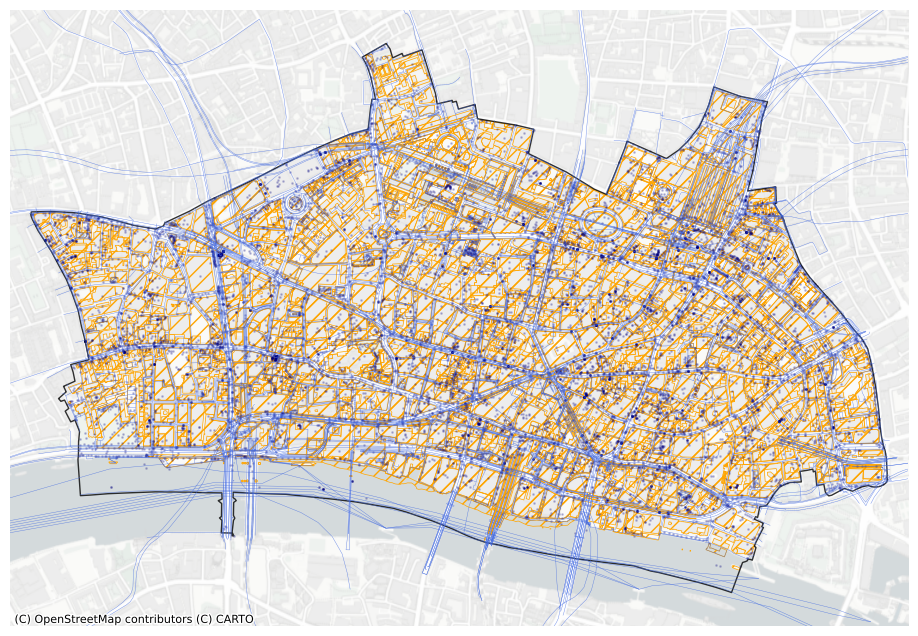

In [22]:
city_of_london_msoa_code = "E02000001"

msoa_area = msoa_stats_gdf.loc[[city_of_london_msoa_code]]
msoa_area_bounds = msoa_area.total_bounds

msoa_features = london_features.loc[
    features_per_msoa.loc[city_of_london_msoa_code].index
]

f, ax = plt.subplots(figsize=(12, 8))

msoa_stats_gdf.loc[[city_of_london_msoa_code]].boundary.plot(
    ax=ax, color="black", alpha=0.8, lw=1
)

# Plot polygons
# We will remove Polygon features that aren't fully within the area for clarity.
msoa_features[
    msoa_features.geom_type.isin(("Polygon", "MultiPolygon"))
    & msoa_features.within(msoa_area.union_all())
].plot(
    ax=ax,
    color=(0, 0, 0, 0),
    lw=0.5,
    hatch="//",
    edgecolor="orange",
)

# Plot linestrings
msoa_features[msoa_features.geom_type == "LineString"].plot(
    ax=ax, color="royalblue", alpha=0.8, lw=0.3
)

# Plot points
msoa_features[msoa_features.geom_type == "Point"].plot(
    ax=ax, color="navy", alpha=0.2, markersize=1
)

ax.set_xlim(msoa_area_bounds[0] - 1e-3, msoa_area_bounds[2] + 1e-3)
ax.set_ylim(msoa_area_bounds[1] - 1e-3, msoa_area_bounds[3] + 1e-3)

cx.add_basemap(
    ax, crs=msoa_stats_gdf.crs, source=cx.providers.CartoDB.PositronNoLabels, zoom=15
)
ax.set_axis_off()

plt.show()

### Calculate the embedding

Here we will transform the data and return a count of features in each region.

We will use the `CountEmbedder` with optimized implementation, but you can try to do it manually.

In [23]:
embeddings = CountEmbedder(count_subcategories=False).transform(
    msoa_stats_gdf, london_features, features_per_msoa
)
embeddings

,base|infrastructure|aerialway,base|infrastructure|airport,base|infrastructure|barrier,base|infrastructure|bridge,base|infrastructure|communication,base|infrastructure|emergency,base|infrastructure|manhole,base|infrastructure|pedestrian,base|infrastructure|pier,base|infrastructure|power,...,places|place|professional_services,places|place|public_service_and_government,places|place|real_estate,places|place|religious_organization,places|place|retail,places|place|structure_and_geography,places|place|travel,transportation|segment|rail,transportation|segment|road,transportation|segment|water
region_id,,,,,,,,,,,,,,,,,,,,,
E02000245,0,0,54,16,0,0,0,13,0,248,...,14,3,2,1,15,0,2,0,543,0
E02000308,0,0,209,42,0,0,0,43,0,4,...,25,11,3,6,25,1,11,19,553,0
E02000294,0,0,80,6,1,0,0,5,0,10,...,25,6,4,2,33,1,5,3,357,0
E02000340,0,0,292,44,0,0,0,74,0,13,...,69,16,8,4,118,1,11,3,1222,0
E02006993,4,0,260,26,1,0,0,88,16,203,...,25,3,7,2,86,2,9,12,643,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E02006836,0,0,24,2,0,0,0,17,0,2,...,33,19,4,3,34,0,6,3,532,0
E02000848,0,0,28,0,0,0,0,5,0,0,...,49,7,9,4,71,0,9,0,303,0
E02006853,0,0,209,13,0,0,0,68,5,57,...,55,12,26,3,32,1,4,2,243,2


## Train the model

Now we can use calculated embeddings and our target column to train a simple model.

In [27]:
train_msoa_codes, test_msoa_codes = train_test_split(
    msoa_stats_gdf.index.to_list(),
    test_size=0.33,
    random_state=42,
    stratify=pd.qcut(msoa_stats_gdf["Total"], 5, labels=False), # stratify splits using total population in 5 buckets
)

X_train = embeddings.loc[train_msoa_codes]
X_test = embeddings.loc[test_msoa_codes]
y_train = msoa_stats_gdf.loc[train_msoa_codes, "population_density"]
y_test = msoa_stats_gdf.loc[test_msoa_codes, "population_density"]

In [28]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
y_pred = model.predict(X_test)

r2_score(y_test, y_pred)

0.7218032947680166

### Compare the predictions with original data

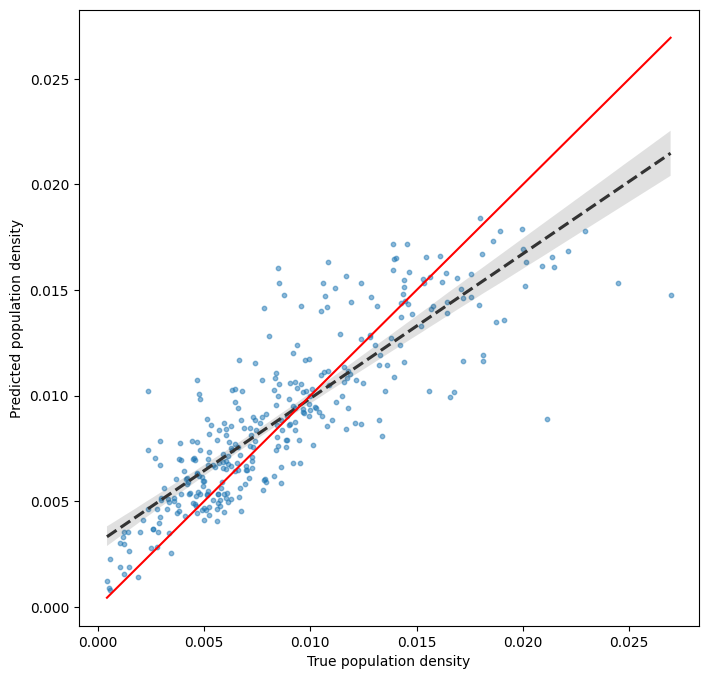

In [30]:
f, ax = plt.subplots(figsize=(8, 8))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws=dict(alpha=0.5, s=10),
    line_kws=dict(color=".2", linestyle="--"),
    ax=ax,
)
min_density = y_test.min()
max_density = y_test.max()
sns.lineplot(
    x=[min_density, max_density], y=[min_density, max_density], color="red", ax=ax
)

ax.set_xlabel("True population density")
ax.set_ylabel("Predicted population density")

plt.show()

### Plot feature importance for the model

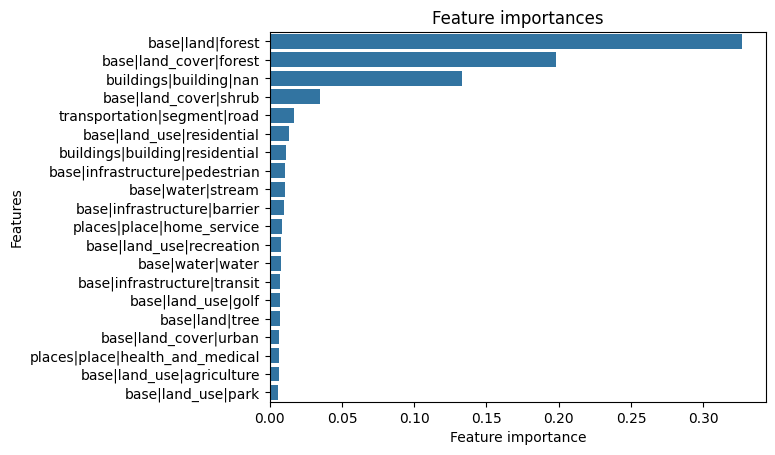

In [31]:
ax = sns.barplot(
    pd.DataFrame(
        {
            "feature_importance": model.feature_importances_,
            "feature_names": embeddings.columns,
        }
    ).nlargest(20, "feature_importance"),
    y="feature_names",
    x="feature_importance",
)
ax.set_title("Feature importances")
ax.set_ylabel("Features")
ax.set_xlabel("Feature importance")
plt.show()

### Predict the data for the whole dataset

In [32]:
msoa_stats_gdf["predicted_population_density"] = model.predict(
    embeddings.loc[msoa_stats_gdf.index]
)

### Explore the results

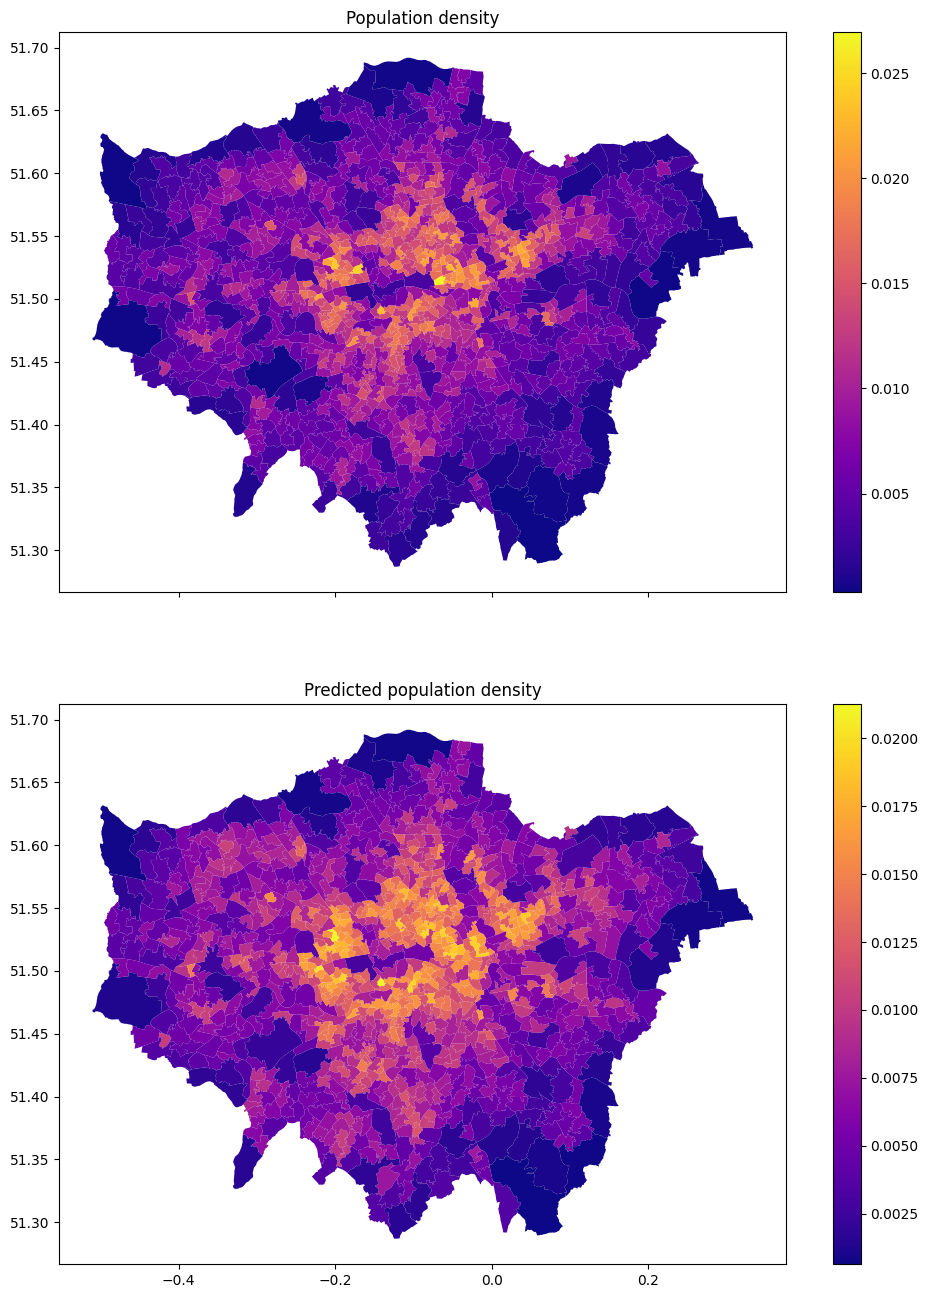

In [33]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16), sharex=True, sharey=True)
msoa_stats_gdf.plot("population_density", ax=ax1, legend=True, cmap="plasma")
msoa_stats_gdf.plot("predicted_population_density", ax=ax2, legend=True, cmap="plasma")

ax1.set_title("Population density")
ax2.set_title("Predicted population density")

plt.show()

Calculate the prediction error and visualize it on a map.

In [34]:
msoa_stats_gdf["error"] = (
    msoa_stats_gdf["population_density"]
    - msoa_stats_gdf["predicted_population_density"]
)

# Rescale from min / max to 0 - 1 with center at 0.5
msoa_stats_gdf["normalized_error"] = (
    msoa_stats_gdf["error"].apply(
        lambda x, city_data=msoa_stats_gdf: (
            -x / city_data["error"].min()
            if x < 0
            else x / city_data["error"].max()
        )
    )
    + 1
) / 2

msoa_stats_gdf["alpha"] = (
    msoa_stats_gdf["normalized_error"] - 0.5
).abs() * 2

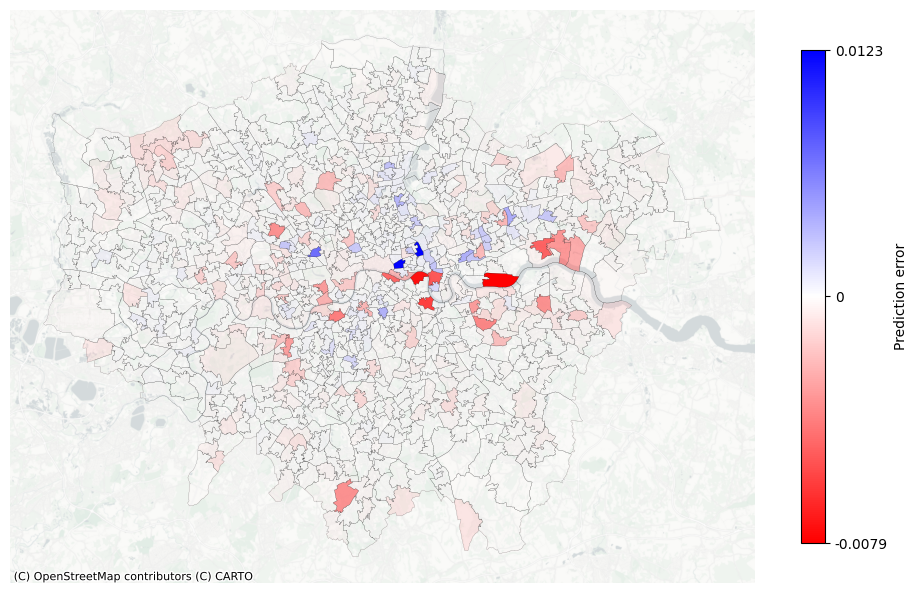

In [35]:
f, ax = plt.subplots(figsize=(12, 8))

msoa_stats_gdf.boundary.plot(ax=ax, color="black", alpha=0.8, lw=0.1)
msoa_stats_gdf.plot(
    "normalized_error",
    ax=ax,
    alpha=msoa_stats_gdf["alpha"],
    cmap="bwr_r",
    legend=True,
    legend_kwds={
        "shrink": 0.8,
        "label": "Prediction error",
        "ticks": [0, 0.5, 1],
        "format": mticker.FixedFormatter(
            [
                round(msoa_stats_gdf["error"].min(), 4),
                "0",
                round(msoa_stats_gdf["error"].max(), 4),
            ]
        ),
    },
)

cx.add_basemap(
    ax, crs=msoa_stats_gdf.crs, source=cx.providers.CartoDB.PositronNoLabels, zoom=12
)
ax.set_axis_off()

plt.show()

## Task for you

- Transform the predicted population density back to a total number of residents.
- Compare the results using a total number of residents and not population density

In [36]:
# Write code here

# You can find answers here: https://github.com/kraina-ai/srai-tutorial/tree/geopython2025/answers